# Clustering — Autoencoder + K-Means
O autoencoder comprime os dados em um espaço latente de menor dimensão, capturando padrões não-lineares. Em seguida, aplicamos K-Means nesse espaço para clustering.

In [1]:
# Instala dependências caso necessário
import subprocess, sys
subprocess.run([sys.executable, '-m', 'pip', 'install', 'torch', '--quiet'], check=False)

CompletedProcess(args=['/Users/marck/Developer/projects/artificial-intelligence-dataset/.venv/bin/python', '-m', 'pip', 'install', 'torch', '--quiet'], returncode=0)

In [2]:
import pickle
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score, davies_bouldin_score

plt.rcParams['figure.figsize'] = (10, 5)
sns.set_theme(style='whitegrid')

SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)

X_scaled = np.load('../dataset/X_scaled.npy')

with open('../dataset/preprocessamento.pkl', 'rb') as f:
    meta = pickle.load(f)

df_orig = meta['df_original']

print(f'Matriz carregada: {X_scaled.shape}')
print(f'PyTorch versão: {torch.__version__}')

Matriz carregada: (2000, 40)
PyTorch versão: 2.12.0


## 1. Arquitetura do Autoencoder
Encoder comprime de `n_features` → `latent_dim`. Decoder reconstrói o original.

In [3]:
class Autoencoder(nn.Module):
    def __init__(self, input_dim, latent_dim=8):
        super().__init__()
        self.encoder = nn.Sequential(
            nn.Linear(input_dim, 64),
            nn.ReLU(),
            nn.Linear(64, 32),
            nn.ReLU(),
            nn.Linear(32, latent_dim)
        )
        self.decoder = nn.Sequential(
            nn.Linear(latent_dim, 32),
            nn.ReLU(),
            nn.Linear(32, 64),
            nn.ReLU(),
            nn.Linear(64, input_dim)
        )

    def forward(self, x):
        z = self.encoder(x)
        return self.decoder(z), z


INPUT_DIM  = X_scaled.shape[1]
LATENT_DIM = 8   # dimensões no espaço latente

model = Autoencoder(INPUT_DIM, LATENT_DIM)
print(model)
total_params = sum(p.numel() for p in model.parameters())
print(f'\nTotal de parâmetros: {total_params:,}')

Autoencoder(
  (encoder): Sequential(
    (0): Linear(in_features=40, out_features=64, bias=True)
    (1): ReLU()
    (2): Linear(in_features=64, out_features=32, bias=True)
    (3): ReLU()
    (4): Linear(in_features=32, out_features=8, bias=True)
  )
  (decoder): Sequential(
    (0): Linear(in_features=8, out_features=32, bias=True)
    (1): ReLU()
    (2): Linear(in_features=32, out_features=64, bias=True)
    (3): ReLU()
    (4): Linear(in_features=64, out_features=40, bias=True)
  )
)

Total de parâmetros: 9,968


## 2. Treinamento

In [4]:
EPOCHS     = 100
BATCH_SIZE = 64
LR         = 1e-3

X_tensor = torch.tensor(X_scaled, dtype=torch.float32)
dataset  = TensorDataset(X_tensor)
loader   = DataLoader(dataset, batch_size=BATCH_SIZE, shuffle=True)

optimizer = torch.optim.Adam(model.parameters(), lr=LR)
criterion = nn.MSELoss()

historico_loss = []

model.train()
for epoch in range(1, EPOCHS + 1):
    epoch_loss = 0.0
    for (batch,) in loader:
        recon, _ = model(batch)
        loss = criterion(recon, batch)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        epoch_loss += loss.item() * len(batch)
    historico_loss.append(epoch_loss / len(X_scaled))
    if epoch % 10 == 0:
        print(f'Época {epoch:3d}/{EPOCHS} | Loss: {historico_loss[-1]:.6f}')

print('Treinamento concluído.')

Época  10/100 | Loss: nan
Época  20/100 | Loss: nan
Época  30/100 | Loss: nan
Época  40/100 | Loss: nan
Época  50/100 | Loss: nan
Época  60/100 | Loss: nan
Época  70/100 | Loss: nan
Época  80/100 | Loss: nan
Época  90/100 | Loss: nan
Época 100/100 | Loss: nan
Treinamento concluído.


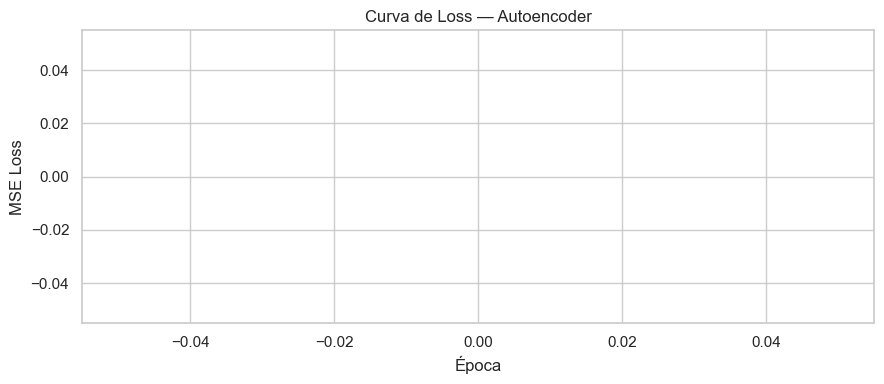

In [5]:
plt.figure(figsize=(9, 4))
plt.plot(historico_loss, color='steelblue')
plt.title('Curva de Loss — Autoencoder')
plt.xlabel('Época')
plt.ylabel('MSE Loss')
plt.tight_layout()
plt.show()

## 3. Extrair representação latente

In [6]:
model.eval()
with torch.no_grad():
    _, Z = model(X_tensor)

Z_np = Z.numpy()
print(f'Espaço latente: {Z_np.shape}  (comprimiu {INPUT_DIM} → {LATENT_DIM} dimensões)')

Espaço latente: (2000, 8)  (comprimiu 40 → 8 dimensões)


## 4. K-Means no espaço latente
> Use o mesmo K do notebook `clustering_03_kmeans.ipynb` para comparação justa.

In [7]:
# Lê o K usado no K-Means original
try:
    with open('../dataset/metricas_kmeans.json') as f:
        K_AE = json.load(f)['k']
    print(f'K carregado do K-Means: {K_AE}')
except FileNotFoundError:
    K_AE = 3
    print(f'Arquivo não encontrado. Usando K={K_AE} (padrão).')

Arquivo não encontrado. Usando K=3 (padrão).


In [8]:
kmeans_ae = KMeans(n_clusters=K_AE, random_state=SEED, n_init=10)
labels_ae = kmeans_ae.fit_predict(Z_np)

sil = silhouette_score(Z_np, labels_ae)
dbi = davies_bouldin_score(Z_np, labels_ae)

print(f'K-Means no espaço latente (K={K_AE})')
print(f'  Silhouette Score : {sil:.4f}')
print(f'  Davies-Bouldin   : {dbi:.4f}')
print(f'  Tamanho dos clusters: {pd.Series(labels_ae).value_counts().sort_index().to_dict()}')

ValueError: Input X contains NaN.
KMeans does not accept missing values encoded as NaN natively. For supervised learning, you might want to consider sklearn.ensemble.HistGradientBoostingClassifier and Regressor which accept missing values encoded as NaNs natively. Alternatively, it is possible to preprocess the data, for instance by using an imputer transformer in a pipeline or drop samples with missing values. See https://scikit-learn.org/stable/modules/impute.html You can find a list of all estimators that handle NaN values at the following page: https://scikit-learn.org/stable/modules/impute.html#estimators-that-handle-nan-values

## 5. Visualização — espaço latente projetado em 2D

In [9]:
pca = PCA(n_components=2, random_state=SEED)
Z_pca = pca.fit_transform(Z_np)

palette = plt.cm.tab10.colors

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Clusters do autoencoder
for c in range(K_AE):
    mask = labels_ae == c
    axes[0].scatter(Z_pca[mask, 0], Z_pca[mask, 1],
                    color=palette[c], label=f'Cluster {c}', alpha=0.5, s=25)
axes[0].set_title(f'Autoencoder + K-Means (K={K_AE}) — Espaço Latente')
axes[0].set_xlabel('PC1'); axes[0].set_ylabel('PC2')
axes[0].legend()

# Job Status real (para comparar)
job_status = df_orig['Job_Status'].values
cores = {'Replaced': '#e74c3c', 'Modified': '#f39c12', 'Unchanged': '#2ecc71'}
for status, cor in cores.items():
    mask = job_status == status
    axes[1].scatter(Z_pca[mask, 0], Z_pca[mask, 1],
                    c=cor, label=status, alpha=0.5, s=25)
axes[1].set_title('Job Status Real — Espaço Latente')
axes[1].set_xlabel('PC1'); axes[1].set_ylabel('PC2')
axes[1].legend()

plt.suptitle('Comparação: Clusters Descobertos vs. Rótulos Reais', fontsize=13)
plt.tight_layout()
plt.show()

ValueError: Input X contains NaN.
PCA does not accept missing values encoded as NaN natively. For supervised learning, you might want to consider sklearn.ensemble.HistGradientBoostingClassifier and Regressor which accept missing values encoded as NaNs natively. Alternatively, it is possible to preprocess the data, for instance by using an imputer transformer in a pipeline or drop samples with missing values. See https://scikit-learn.org/stable/modules/impute.html You can find a list of all estimators that handle NaN values at the following page: https://scikit-learn.org/stable/modules/impute.html#estimators-that-handle-nan-values

## 6. Perfil dos clusters

In [ ]:
df_perfil = df_orig.copy()
df_perfil['Cluster'] = labels_ae

num_cols = ['Age', 'Years_Experience', 'Salary_Before_AI', 'Work_Hours_Per_Week', 'Job_Satisfaction']

print('=== MÉDIAS NUMÉRICAS POR CLUSTER ===')
display(df_perfil.groupby('Cluster')[num_cols].mean().round(1))

print('\n=== JOB STATUS POR CLUSTER (%) ===')
status_pct = (df_perfil.groupby(['Cluster', 'Job_Status'])
                         .size()
                         .unstack(fill_value=0)
                         .apply(lambda r: r / r.sum() * 100, axis=1)
                         .round(1))
display(status_pct)

## 7. Salvar resultados

In [ ]:
np.save('../dataset/labels_autoencoder.npy', labels_ae)
np.save('../dataset/Z_latente.npy', Z_np)

metricas_ae = {'silhouette': float(sil), 'davies_bouldin': float(dbi), 'k': K_AE, 'latent_dim': LATENT_DIM}
with open('../dataset/metricas_autoencoder.json', 'w') as f:
    json.dump(metricas_ae, f)

torch.save(model.state_dict(), '../dataset/autoencoder_weights.pt')

print('Labels, métricas e pesos do modelo salvos.')